In [17]:
import os, json, random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

print("torch:", torch.__version__)
print("albumentations:", A.__version__)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

CONFIG_PATHS = {
    "split_csv": "/kaggle/input/notebooks/sumaiyahoque/nb-0-eda-and-data-prep/split.csv",
    "output_dir": "/kaggle/working/",
}

MASK_THRESHOLD = 127
IMG_SIZE = 512
NUM_CLASSES = 2

torch: 2.10.0+cu128
albumentations: 2.0.8
Device: cuda


Load Part A's Split, Unmodified

In [18]:
df = pd.read_csv(CONFIG_PATHS["split_csv"])
assert set(df["split"].unique()) == {"train", "val", "test"}
print(df["split"].value_counts())

split
train    1035
val       318
test      168
Name: count, dtype: int64


In [19]:
train_patients = set(df[df["split"] == "train"]["patient_id"])
val_patients   = set(df[df["split"] == "val"]["patient_id"])
test_patients  = set(df[df["split"] == "test"]["patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)
print("No patient leakage across splits — confirmed.")

No patient leakage across splits — confirmed.


Split Role Mapping

In [20]:
print(f"""
Split Role Mapping (Part B):
  Train (n={len(df[df.split=='train'])}) -> Unlabelled SSL pretraining corpus
  Val   (n={len(df[df.split=='val'])})    -> Labelled fine-tuning set
  Test  (n={len(df[df.split=='test'])})   -> Monitoring (during FT) + Final evaluation

Label efficiency ratio: {len(df[df.split=='val'])}/{len(df[df.split=='train'])} =
{len(df[df.split=='val'])/len(df[df.split=='train']):.1%} of Part-A's training data
""")


Split Role Mapping (Part B):
  Train (n=1035) -> Unlabelled SSL pretraining corpus
  Val   (n=318)    -> Labelled fine-tuning set
  Test  (n=168)   -> Monitoring (during FT) + Final evaluation

Label efficiency ratio: 318/1035 =
30.7% of Part-A's training data



Train Loader: Unlabelled, Two Augmented Views (No Masks)

In [21]:
class UnlabelledTwoViewDataset(Dataset):
    """Train-split images only. Masks are never touched here."""
    def __init__(self, dataframe, transform):
        self.img_paths = dataframe["img_path"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.img_paths[idx]), cv2.COLOR_BGR2RGB)
        view1 = self.transform(image=img)["image"]
        view2 = self.transform(image=img)["image"]
        return view1, view2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

ssl_train_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.2, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.8),
    A.GaussianBlur(blur_limit=(3, 5), p=0.5),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ssl_ds = UnlabelledTwoViewDataset(df[df["split"] == "train"], ssl_train_transform)
print(f"Unlabelled SSL pretraining set: {len(train_ssl_ds)} images")

Unlabelled SSL pretraining set: 1035 images


Validation Loader: Synced Image + Mask

In [22]:
class SegDataset(Dataset):
    def __init__(self, dataframe, transform=None, mask_threshold=MASK_THRESHOLD):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.mask_threshold = mask_threshold

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask >= self.mask_threshold).astype(np.uint8)

        if mask.shape[:2] != img.shape[:2]:
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]),
                               interpolation=cv2.INTER_NEAREST)

        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        img = img.astype(np.float32) / 255.0
        img = (img - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)
        img = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask).long()

        return img, mask, row["img_path"]

finetune_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-15, 15), p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
])

finetune_ds = SegDataset(df[df["split"] == "val"], transform=finetune_transform)
print(f"Labelled fine-tuning set: {len(finetune_ds)} images (+ masks)")

Labelled fine-tuning set: 318 images (+ masks)


In [23]:
test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])

test_ds = SegDataset(df[df["split"] == "test"], transform=test_transform)
print(f"Test (monitoring + final eval) set: {len(test_ds)} images (+ masks)")

Test (monitoring + final eval) set: 168 images (+ masks)


Sanity-Check Visualization

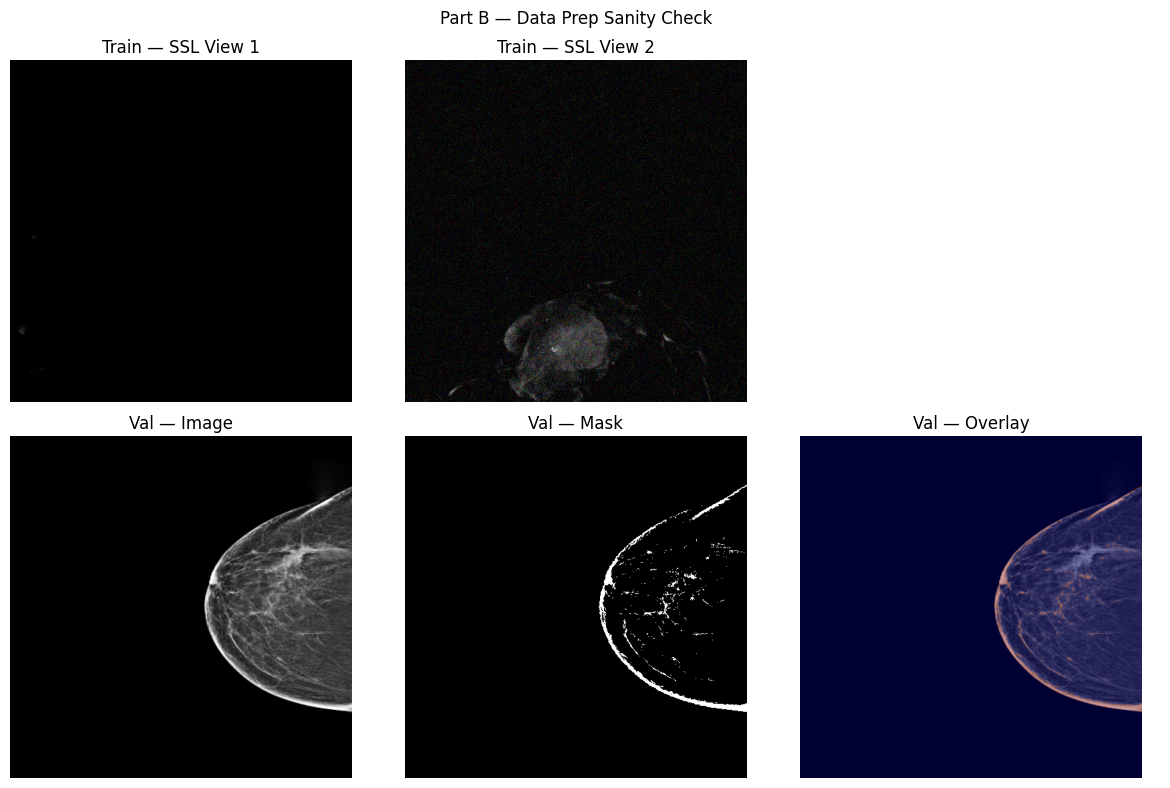

Confirm before proceeding to SSL notebooks:
 1. Two SSL views look like different crops/augmentations of the SAME image
 2. Validation mask overlay aligns with the lesion region
 3. No destroyed/empty mask from augmentation


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

def denorm(t):
    if isinstance(t, torch.Tensor):
        t = t.detach().cpu()
        t = t.permute(1, 2, 0).numpy()
    else:
        t = np.asarray(t)
        if t.ndim == 3 and t.shape[0] == 3:
            t = np.transpose(t, (1, 2, 0))

    mean = np.array(IMAGENET_MEAN, dtype=np.float32).reshape(1, 1, 3)
    std = np.array(IMAGENET_STD, dtype=np.float32).reshape(1, 1, 3)

    return np.clip(t * std + mean, 0, 1)

v1, v2 = train_ssl_ds[0]
axes[0, 0].imshow(denorm(v1)); axes[0, 0].set_title("Train — SSL View 1")
axes[0, 1].imshow(denorm(v2)); axes[0, 1].set_title("Train — SSL View 2")
axes[0, 2].axis("off")

img, mask, path = finetune_ds[0]
axes[1, 0].imshow(denorm(img)); axes[1, 0].set_title("Val — Image")
axes[1, 1].imshow(mask.numpy(), cmap="gray"); axes[1, 1].set_title("Val — Mask")
axes[1, 2].imshow(denorm(img)); axes[1, 2].imshow(mask.numpy(), cmap="jet", alpha=0.4)
axes[1, 2].set_title("Val — Overlay")

for ax in axes.flat: ax.axis("off")
plt.suptitle("Part B — Data Prep Sanity Check")
plt.tight_layout()
plt.savefig(f"{CONFIG_PATHS['output_dir']}sanity_check_partB.png", dpi=150)
plt.show()

print("Confirm before proceeding to SSL notebooks:")
print(" 1. Two SSL views look like different crops/augmentations of the SAME image")
print(" 2. Validation mask overlay aligns with the lesion region")
print(" 3. No destroyed/empty mask from augmentation")


In [25]:
os.makedirs(f"{CONFIG_PATHS['output_dir']}splits", exist_ok=True)

df[df["split"] == "train"].to_csv(f"{CONFIG_PATHS['output_dir']}splits/train_unlabelled.csv", index=False)
df[df["split"] == "val"].to_csv(f"{CONFIG_PATHS['output_dir']}splits/val_labelled_finetune.csv", index=False)
df[df["split"] == "test"].to_csv(f"{CONFIG_PATHS['output_dir']}splits/test_monitor_eval.csv", index=False)

meta = {
    "dataset": "BCSD-2024 breast ultrasound lesion segmentation",
    "num_classes": NUM_CLASSES,
    "class_names": ["background", "lesion"],
    "img_size": IMG_SIZE,
    "mask_threshold": MASK_THRESHOLD,
    "train_count": int((df["split"] == "train").sum()),
    "val_count": int((df["split"] == "val").sum()),
    "test_count": int((df["split"] == "test").sum()),
    "part_a_best_model": "SegFormer-B0",
    "part_a_best_miou": 0.8758,
    "label_efficiency_ratio": round(
        (df["split"] == "val").sum() / (df["split"] == "train").sum(), 4
    ),
    "source": "Part A leakage-safe patient-level split (nb-0), roles reassigned for Part B",
}
with open(f"{CONFIG_PATHS['output_dir']}splits/split_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta, indent=2))


{
  "dataset": "BCSD-2024 breast ultrasound lesion segmentation",
  "num_classes": 2,
  "class_names": [
    "background",
    "lesion"
  ],
  "img_size": 512,
  "mask_threshold": 127,
  "train_count": 1035,
  "val_count": 318,
  "test_count": 168,
  "part_a_best_model": "SegFormer-B0",
  "part_a_best_miou": 0.8758,
  "label_efficiency_ratio": 0.3072,
  "source": "Part A leakage-safe patient-level split (nb-0), roles reassigned for Part B"
}


Sanity-Check Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.2456645].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4199564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.7511111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..-0.4101089].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88492167..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2

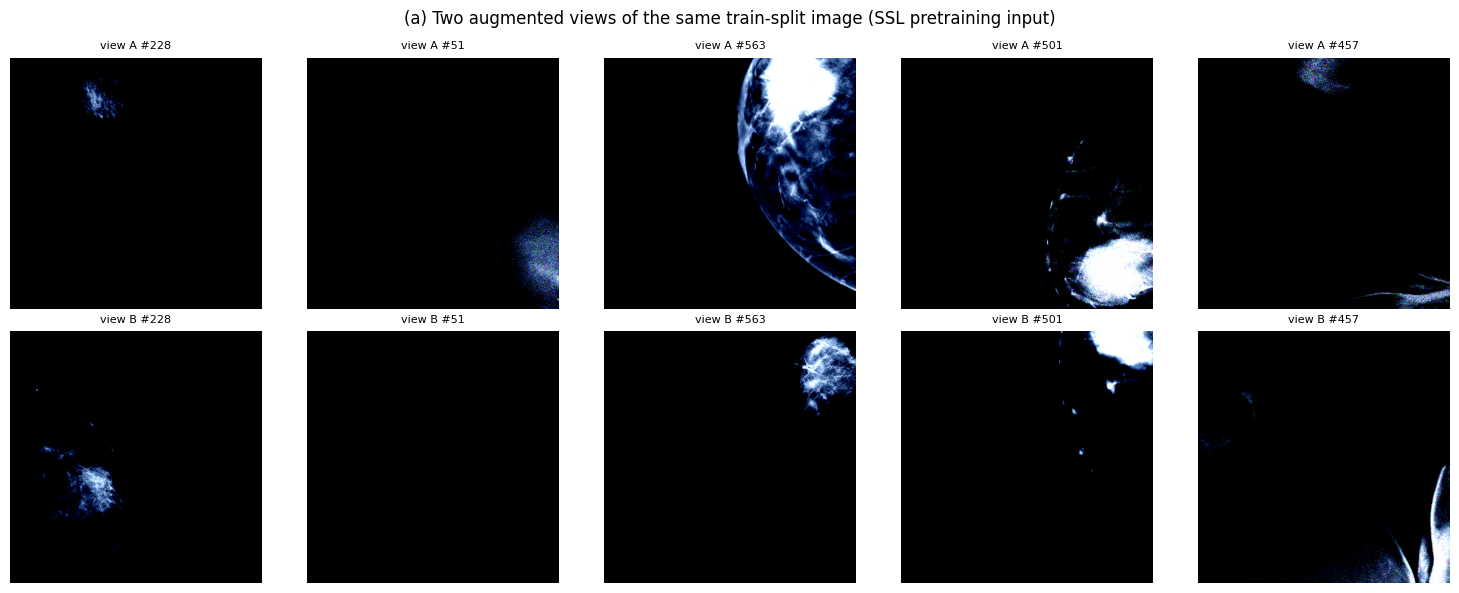

In [26]:
n_show = 5
check_idxs = random.sample(range(len(train_ssl_ds)), min(n_show, len(train_ssl_ds)))

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for col, idx in enumerate(check_idxs):
    v1, v2 = train_ssl_ds[idx]
    axes[0, col].imshow(v1); axes[0, col].set_title(f"view A #{idx}", fontsize=8); axes[0, col].axis("off")
    axes[1, col].imshow(v2); axes[1, col].set_title(f"view B #{idx}", fontsize=8); axes[1, col].axis("off")
plt.suptitle("(a) Two augmented views of the same train-split image (SSL pretraining input)")
plt.tight_layout()
plt.show()


In [27]:
os.makedirs(f"{CONFIG_PATHS['output_dir']}splits", exist_ok=True)

df[df["split"] == "train"].to_csv(f"{CONFIG_PATHS['output_dir']}splits/train_unlabelled.csv", index=False)
df[df["split"] == "val"].to_csv(f"{CONFIG_PATHS['output_dir']}splits/val_labelled_finetune.csv", index=False)
df[df["split"] == "test"].to_csv(f"{CONFIG_PATHS['output_dir']}splits/test_monitor_eval.csv", index=False)

meta = {
    "dataset": "BCSD-2024 breast ultrasound lesion segmentation",
    "num_classes": NUM_CLASSES,
    "class_names": ["background", "lesion"],
    "img_size": IMG_SIZE,
    "mask_threshold": MASK_THRESHOLD,
    "train_count": int((df["split"] == "train").sum()),
    "val_count": int((df["split"] == "val").sum()),
    "test_count": int((df["split"] == "test").sum()),
    "part_a_best_model": "SegFormer-B0",
    "part_a_best_miou": 0.8758,
    "label_efficiency_ratio": round(
        (df["split"] == "val").sum() / (df["split"] == "train").sum(), 4
    ),
    "source": "Part A leakage-safe patient-level split (nb-0), roles reassigned for Part B",
}
with open(f"{CONFIG_PATHS['output_dir']}splits/split_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta, indent=2))


{
  "dataset": "BCSD-2024 breast ultrasound lesion segmentation",
  "num_classes": 2,
  "class_names": [
    "background",
    "lesion"
  ],
  "img_size": 512,
  "mask_threshold": 127,
  "train_count": 1035,
  "val_count": 318,
  "test_count": 168,
  "part_a_best_model": "SegFormer-B0",
  "part_a_best_miou": 0.8758,
  "label_efficiency_ratio": 0.3072,
  "source": "Part A leakage-safe patient-level split (nb-0), roles reassigned for Part B"
}
